# Module 01 · Giới thiệu: vì sao dùng biến đổi Fourier

**Nguồn sách:** Bracewell, chương 1, tr. 1–4

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".6g"):
    """In một kết quả có tên (trang web đọc các dòng bắt đầu bằng ▸)."""
    print(f"▸ {key} = {value:{fmt}}")


## 1. Dạng sóng và phổ
🎯 **Phương pháp này trả lời câu hỏi gì?** Trong tín hiệu gồm nhiều sóng hình sin trộn lẫn, mỗi tần số đóng góp bao nhiêu biên độ, và khi nào phép đọc phổ sai lệch? Ta tính bằng hai cách độc lập: FFT và tổng trực tiếp $X_k=\sum_n x_n e^{-i2\pi kn/N}$ ("biến đổi Fourier chậm" của Bracewell).

In [2]:
fs, N = 1000, 1000                       # tần số lấy mẫu (Hz) và số mẫu: đúng 1 giây, nên 1 ô tần số = 1 Hz
t = np.arange(N) / fs
x = 1.0*np.sin(2*np.pi*50*t) + 0.5*np.cos(2*np.pi*120*t) + 0.25*np.sin(2*np.pi*300*t)

# Cách A: FFT
amp_fft = amplitude_spectrum(x)

# Cách B: tổng trực tiếp theo định nghĩa (không dùng FFT)
n = np.arange(N)
amp_direct = np.array([2*abs(np.sum(x*np.exp(-2j*np.pi*k*n/N)))/N for k in range(N//2 + 1)])
amp_direct[0] /= 2

diff = np.max(np.abs(amp_fft - amp_direct))
assert diff < 1e-9
report("fft_direct_diff", diff, ".1e")
for f in (50, 120, 300):
    report(f"a{f}", amp_fft[f], ".6f")

others = np.ones(len(amp_fft), bool); others[[50, 120, 300]] = False
assert amp_fft[others].max() < 1e-9      # mọi ô tần số khác đều bằng 0

▸ fft_direct_diff = 2.4e-14
▸ a50 = 1.000000
▸ a120 = 0.500000
▸ a300 = 0.250000


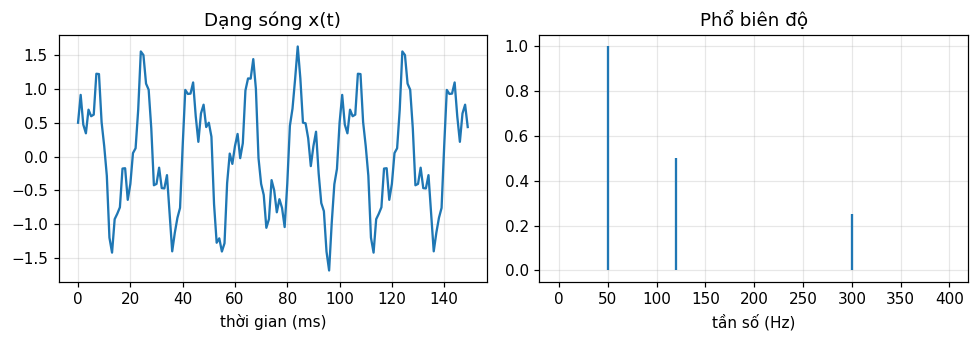

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(t[:150]*1000, x[:150])
ax[0].set_xlabel("thời gian (ms)"); ax[0].set_title("Dạng sóng x(t)")
ax[1].vlines(np.arange(400), 0, amp_fft[:400])
ax[1].set_xlabel("tần số (Hz)"); ax[1].set_title("Phổ biên độ")
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Ba biên độ phục hồi được là 1.000000 (50 Hz), 0.500000 (120 Hz) và 0.250000 (300 Hz), đúng bằng các hệ số đã cài vào tín hiệu. Hai phương pháp độc lập lệch nhau tối đa 2.4e-14, tức là chỉ khác nhau ở sai số làm tròn, và mọi ô tần số còn lại bằng 0. Đây là ý nghĩa của "dạng sóng và phổ mang cùng thông tin": từ 1000 mẫu phức tạp ta rút ra đúng 6 con số (3 biên độ, 3 tần số).

In [4]:
# Rò phổ: 50.5 Hz không rơi đúng vào ô tần số nào (nằm giữa ô 50 và ô 51)
xl = np.sin(2*np.pi*50.5*t)
al = amplitude_spectrum(xl)
pred = abs(np.sinc(0.5))                 # dự đoán A|sinc(δ)| với δ = 0.5 ô
assert abs(al[50] - pred) < 0.01 and abs(al[51] - pred) < 0.01
report("leak_peak", al[50], ".4f"); report("leak_theory", pred, ".4f"); report("leak_far", al[80], ".4f")

# Pha của sin và cos
ph_sin = np.degrees(np.angle(np.fft.rfft(np.sin(2*np.pi*50*t))[50]))
ph_cos = np.degrees(np.angle(np.fft.rfft(np.cos(2*np.pi*120*t))[120]))
assert abs(ph_sin + 90) < 1e-6 and abs(ph_cos) < 1e-6
report("ph_sin", round(ph_sin, 1) + 0.0, ".1f"); report("ph_cos", round(ph_cos, 1) + 0.0, ".1f")

# Tính tuyến tính của phép biến đổi
x1, x2 = np.sin(2*np.pi*50*t), np.cos(2*np.pi*120*t)
lin_err = np.max(np.abs(np.fft.rfft(x1 + x2) - (np.fft.rfft(x1) + np.fft.rfft(x2))))
assert lin_err < 1e-9
report("lin_err", lin_err, ".1e")

▸ leak_peak = 0.6397
▸ leak_theory = 0.6366
▸ leak_far = 0.0085
▸ ph_sin = -90.0
▸ ph_cos = 0.0
▸ lin_err = 6.2e-14


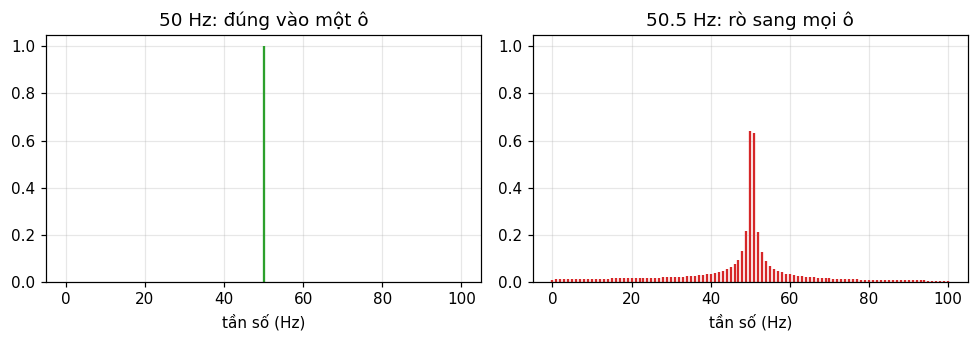

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].vlines(np.arange(0, 101), 0, amplitude_spectrum(np.sin(2*np.pi*50*t))[:101], colors="tab:green")
ax[0].set_title("50 Hz: đúng vào một ô")
ax[1].vlines(np.arange(0, 101), 0, al[:101], colors="tab:red")
ax[1].set_title("50.5 Hz: rò sang mọi ô")
for a_ in ax: a_.set_xlabel("tần số (Hz)"); a_.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Sóng 50.5 Hz cho biên độ ô 50 là 0.6397 thay vì 1; dự đoán $|\text{sinc}(0.5)|$ là 0.6366, khớp trong 0.01. Ngay cả ô 80, cách đỉnh 30 ô, vẫn còn 0.0085: đây là rò phổ, hệ quả của việc cắt tín hiệu bằng cửa sổ chữ nhật. Pha của $\sin$ tại ô 50 là -90.0 độ và của $\cos$ tại ô 120 là 0.0 độ. Tính tuyến tính của phép biến đổi được xác nhận: sai lệch 6.2e-14.

## 2. Năng lượng và tích chập: hai phép kiểm số cổ điển
🎯 **Phương pháp này trả lời câu hỏi gì?** Đổi miền có làm mất hay thêm thông tin không, và tích chập trong miền gốc có đúng là phép nhân trong miền tần số không? Ta kiểm bằng bảo toàn năng lượng và bằng ví dụ tích chập nối tiếp của Bracewell (tr. 32).

In [6]:
# Tín hiệu xác định (không ngẫu nhiên) để kết quả tái lập được
n = np.arange(1000)
xr = np.cos(2*np.pi*7*n/1000)*np.exp(-n/300) + 0.3*np.sin(2*np.pi*41*n/1000)
e_time = np.sum(xr**2)
e_freq = np.sum(np.abs(np.fft.fft(xr))**2)/len(xr)
assert np.isclose(e_time, e_freq)
report("energy_time", e_time, ".6f"); report("energy_freq", e_freq, ".6f")

# Tích chập nối tiếp của Bracewell (tr. 32)
f = np.array([2, 2, 3, 3, 4]); g = np.array([1, 1, 2])
c_direct = np.convolve(f, g)                                   # cách A: tổng trực tiếp
L = len(f) + len(g) - 1
c_fft = np.fft.irfft(np.fft.rfft(f, L)*np.fft.rfft(g, L), L)   # cách B: nhân hai FFT rồi biến đổi ngược
assert np.allclose(c_direct, c_fft)
assert c_direct.sum() == f.sum()*g.sum()
report("conv_direct", " ".join(str(v) for v in c_direct), "s")
report("sum_f", int(f.sum()), "d"); report("sum_g", int(g.sum()), "d"); report("conv_sum", int(c_direct.sum()), "d")

▸ energy_time = 123.132814
▸ energy_freq = 123.132814
▸ conv_direct = 2 4 9 10 13 10 8
▸ sum_f = 14
▸ sum_g = 4
▸ conv_sum = 56


#### 📤 Đầu ra thật
Năng lượng theo thời gian 123.132814 bằng năng lượng theo tần số 123.132814: đổi miền không làm mất thông tin. Tích chập nối tiếp cho dãy 2 4 9 10 13 10 8 bằng cả hai cách, đúng như Bracewell tính tay, và tổng các số hạng 56 bằng tích hai tổng 14 nhân 4.

## 3. Hệ tuyến tính bất biến giữ nguyên tần số
🎯 **Phương pháp này trả lời câu hỏi gì?** Bộ lọc thông thấp $y[n]=a\,y[n-1]+(1-a)x[n]$ làm gì với sóng hình sin? Ta đo độ lợi và pha bằng FFT, đối chiếu công thức đáp ứng tần số $H(\omega)=\dfrac{1-a}{1-a\,e^{-i\omega}}$, và đối chiếu đáp ứng xung $h[n]=(1-a)a^n$ với hàm <code>lfilter</code>.

In [7]:
from scipy.signal import lfilter

a = 0.9                                  # hệ số bộ lọc

def lowpass_loop(x, a):                  # cách viết tay bằng vòng lặp, độc lập với SciPy
    y, prev = np.zeros_like(x), 0.0
    for i, xi in enumerate(x):
        prev = a*prev + (1 - a)*xi
        y[i] = prev
    return y

x0 = np.sin(2*np.pi*50*np.arange(2000)/fs + 0.3)   # sóng 50 Hz, pha đầu 0.3 rad, dài 2 s
y_scipy = lfilter([1 - a], [1, -a], x0)
y_loop = lowpass_loop(x0, a)
assert np.allclose(y_scipy, y_loop)

# Đáp ứng xung h[n] và tích chập trực tiếp
h = (1 - a)*a**np.arange(300)
y_conv = np.convolve(x0, h)[:len(x0)]
conv_diff = np.max(np.abs(y_conv - y_scipy))
assert conv_diff < 1e-9
report("conv_lfilter_diff", conv_diff, ".1e"); report("h_sum", h.sum(), ".6f")

xs, ys = x0[1000:], y_scipy[1000:]       # bỏ 1 s đầu (quá độ), phân tích 1 s ổn định
Xs, Ys = np.fft.rfft(xs), np.fft.rfft(ys)
f_out = int(np.argmax(np.abs(Ys)))
gain_meas = abs(Ys[50]) / abs(Xs[50])
phase_meas = np.angle(np.exp(1j*(np.angle(Ys[50]) - np.angle(Xs[50]))))

w = 2*np.pi*50/fs
H = (1 - a)/(1 - a*np.exp(-1j*w))        # đáp ứng tần số theo lý thuyết
assert abs(gain_meas - abs(H)) < 1e-6 and abs(phase_meas - np.angle(H)) < 1e-6

report("f_out", f_out, "d")
report("gain_meas", gain_meas, ".6f");   report("gain_theory", abs(H), ".6f")
report("phase_meas_deg", np.degrees(phase_meas), ".3f");  report("phase_theory_deg", np.degrees(np.angle(H)), ".3f")

# Đo độ lợi ở nhiều tần số
meas = {50: gain_meas}
for fq in (25, 100, 200):
    xin = np.sin(2*np.pi*fq*np.arange(2000)/fs)
    yout = lfilter([1 - a], [1, -a], xin)[1000:]
    G = abs(np.fft.rfft(yout)[fq]) / abs(np.fft.rfft(xin[1000:])[fq])
    Ht = abs((1 - a)/(1 - a*np.exp(-1j*2*np.pi*fq/fs)))
    assert abs(G - Ht) < 1e-6
    meas[fq] = G
    report(f"gain_{fq}", G, ".6f")

▸ conv_lfilter_diff = 8.2e-15
▸ h_sum = 1.000000
▸ f_out = 50
▸ gain_meas = 0.319278
▸ gain_theory = 0.319278
▸ phase_meas_deg = -62.618
▸ phase_theory_deg = -62.618
▸ gain_25 = 0.557616
▸ gain_100 = 0.168128
▸ gain_200 = 0.089308


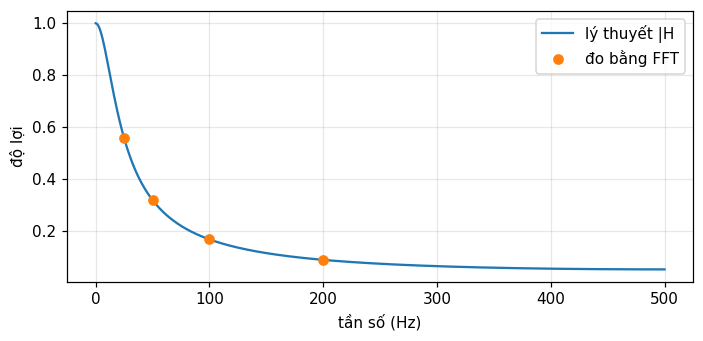

In [8]:
ff = np.linspace(0, 500, 501)
Hc = np.abs((1 - a)/(1 - a*np.exp(-1j*2*np.pi*ff/fs)))
plt.figure(figsize=(6.5, 3.2))
plt.plot(ff, Hc, label="lý thuyết |H")
plt.plot(list(meas), list(meas.values()), "o", label="đo bằng FFT")
plt.xlabel("tần số (Hz)"); plt.ylabel("độ lợi"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Sóng ra vẫn có đỉnh tại 50 Hz: tần số không đổi. Bộ lọc chỉ đổi biên độ (độ lợi đo 0.319278, lý thuyết 0.319278) và pha (đo -62.618 độ, lý thuyết -62.618 độ, dấu âm nghĩa là sóng ra trễ pha). Vòng lặp viết tay, <code>lfilter</code> và tích chập với $h[n]$ cho cùng đáp số (lệch 8.2e-15), và tổng của $h$ là 1.000000 nên độ lợi một chiều bằng 1. Độ lợi giảm dần theo tần số: 0.557616 tại 25 Hz, 0.168128 tại 100 Hz, 0.089308 tại 200 Hz.

## 4. Khi điều kiện bị phá vỡ
🎯 **Phương pháp này trả lời câu hỏi gì?** Nếu hệ phi tuyến (khâu bình phương, khâu bậc ba) hoặc thay đổi theo thời gian (bộ nhân với cosin) thì phổ ra khác gì hệ tuyến tính bất biến? Khác với phần 3, ở đây tần số ra không còn bằng tần số vào.

In [9]:
xt = np.sin(2*np.pi*50*np.arange(1000)/fs)

# Hệ phi tuyến: khâu bình phương
An = amplitude_spectrum(xt**2)
nl_dc, nl_a100, nl_a50 = An[0], An[100], An[50]

# Hệ tuyến tính nhưng thay đổi theo thời gian: nhân với cos(2π·20t)
At = amplitude_spectrum(xt*np.cos(2*np.pi*20*np.arange(1000)/fs))
tv_a30, tv_a70, tv_a50 = At[30], At[70], At[50]

assert abs(nl_dc - 0.5) < 1e-9 and abs(nl_a100 - 0.5) < 1e-9 and nl_a50 < 1e-9
assert abs(tv_a30 - 0.5) < 1e-9 and abs(tv_a70 - 0.5) < 1e-9 and tv_a50 < 1e-9
for k, v in dict(nl_dc=nl_dc, nl_a100=nl_a100, nl_a50=nl_a50, tv_a30=tv_a30, tv_a70=tv_a70).items():
    report(k, abs(v), ".6f")

# Khâu bậc ba y = x + 0.1x³ và méo hài
Ac = amplitude_spectrum(xt + 0.1*xt**3)
fund, h3 = Ac[50], Ac[150]
assert abs(fund - 1.075) < 1e-9 and abs(h3 - 0.025) < 1e-9     # sin³θ = (3 sinθ − sin3θ)/4
report("cubic_fund", fund, ".6f"); report("cubic_h3", h3, ".6f"); report("cubic_thd_pct", 100*h3/fund, ".4f")

▸ nl_dc = 0.500000
▸ nl_a100 = 0.500000
▸ nl_a50 = 0.000000
▸ tv_a30 = 0.500000
▸ tv_a70 = 0.500000
▸ cubic_fund = 1.075000
▸ cubic_h3 = 0.025000
▸ cubic_thd_pct = 2.3256


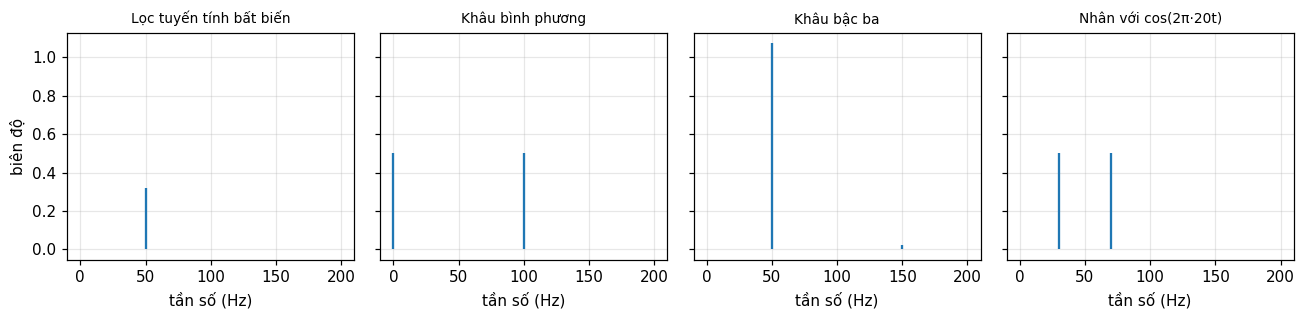

In [10]:
fr = np.arange(0, 201)
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
panels = [(amplitude_spectrum(ys), "Lọc tuyến tính bất biến"),
          (An, "Khâu bình phương"),
          (Ac, "Khâu bậc ba"),
          (At, "Nhân với cos(2π·20t)")]
for a_, (s, ttl) in zip(ax, panels):
    a_.vlines(fr, 0, s[:201]); a_.set_title(ttl, fontsize=9); a_.set_xlabel("tần số (Hz)")
ax[0].set_ylabel("biên độ")
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Khâu bình phương cho một chiều 0.500000 và 100 Hz biên độ 0.500000, còn 50 Hz chỉ 0.000000. Bộ nhân với cosin cho 30 Hz và 70 Hz cùng biên độ 0.500000 và 0.500000 (công thức $\cos A\cos B=\tfrac12[\cos(A-B)+\cos(A+B)]$). Khâu bậc ba cho cơ bản 1.075000 và hài bậc ba 0.025000, tức THD 2.3256%, đúng theo $\sin^3\theta=\tfrac34\sin\theta-\tfrac14\sin3\theta$. Kết luận: vạch phổ tại tần số lạ là chữ ký của phi tuyến hoặc của hệ thay đổi theo thời gian. Đó là lý do lý thuyết trong giáo trình đặt nền trên hệ tuyến tính bất biến, nơi đáp ứng là một tích chập.

## 5. Ký hiệu: hàm cổng, tích chập và xung
🎯 **Phương pháp này trả lời câu hỏi gì?** Các ký hiệu $\Pi$, $*$ và $\delta$ có đúng như giáo trình mô tả không? Ta kiểm bằng tích phân số so với công thức đóng, và bằng dãy xung chữ nhật $\delta_\varepsilon$ hẹp dần.

In [11]:
from scipy import integrate, special

# Hàm cổng: ∫ Π(x) cos(πx) dx = ∫ từ −1/2 đến 1/2 của cos(πx) = 2/π
gate_area, _ = integrate.quad(lambda u: np.cos(np.pi*u), -0.5, 0.5)
assert abs(gate_area - 2/np.pi) < 1e-12
report("gate_area", gate_area, ".6f")

# Trung bình trượt Π*f tại x = 0 với f(u) = exp(−u²): tích phân số so với √π·erf(1/2)
run_num, _ = integrate.quad(lambda u: np.exp(-u**2), -0.5, 0.5)
run_exact = np.sqrt(np.pi)*special.erf(0.5)
assert abs(run_num - run_exact) < 1e-12
report("run_mean_num", run_num, ".6f"); report("run_mean_exact", run_exact, ".6f")

# Tính chất "sàng" của xung: ∫ cos(x) δ_ε(x) dx → cos(0) = 1
for tag, eps in (("e05", 0.5), ("e01", 0.1), ("e001", 0.01)):
    val, _ = integrate.quad(lambda u: np.cos(u)/eps, -eps/2, eps/2)
    exact = 2*np.sin(eps/2)/eps
    assert abs(val - exact) < 1e-12
    report(f"sift_{tag}", val, ".6f")

▸ gate_area = 0.636620
▸ run_mean_num = 0.922562
▸ run_mean_exact = 0.922562
▸ sift_e05 = 0.989616
▸ sift_e01 = 0.999583
▸ sift_e001 = 0.999996


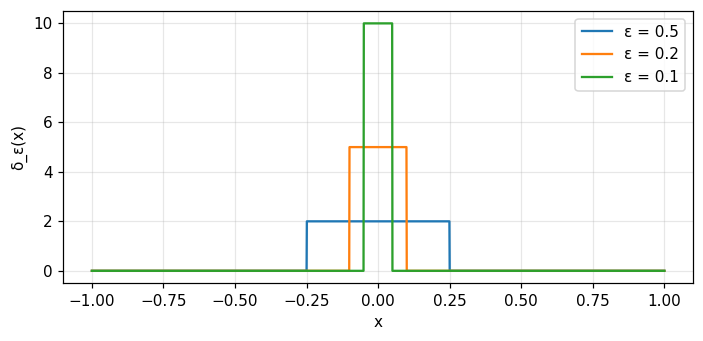

In [12]:
xx = np.linspace(-1, 1, 2001)
plt.figure(figsize=(6.5, 3.2))
for eps, c in ((0.5, "tab:blue"), (0.2, "tab:orange"), (0.1, "tab:green")):
    plt.plot(xx, np.where(np.abs(xx) < eps/2, 1/eps, 0.0), color=c, label=f"ε = {eps}")
plt.xlabel("x"); plt.ylabel("δ_ε(x)"); plt.legend()
plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tích phân $\int\Pi(x)\cos(\pi x)\,dx$ bằng 0.636620, đúng $2/\pi$. Trung bình trượt của $e^{-u^2}$ tại gốc là 0.922562 bằng tích phân số và 0.922562 bằng công thức đóng. Bảng "sàng": 0.989616 với ε=0.5, 0.999583 với ε=0.1, 0.999996 với ε=0.01, tiến dần tới $\cos 0=1$. Vậy biểu thức chứa $\delta$ có nghĩa đúng như Bracewell mô tả: là giới hạn của dãy xung có bề rộng, không phải một hàm tại một điểm.